In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib
import os

In [2]:
df = pd.read_csv("../dataset/diabetes_prediction_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [5]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
df["diabetes"].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

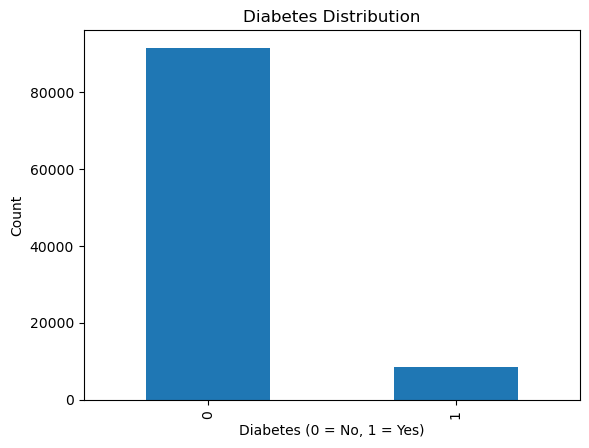

In [7]:
df["diabetes"].value_counts().plot(kind="bar")
plt.title("Diabetes Distribution")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


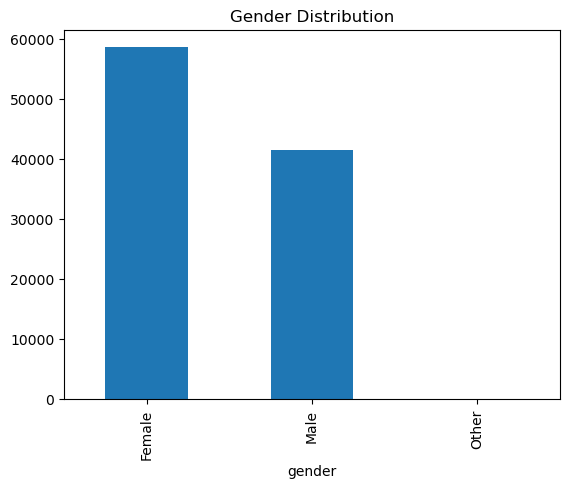

In [8]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()


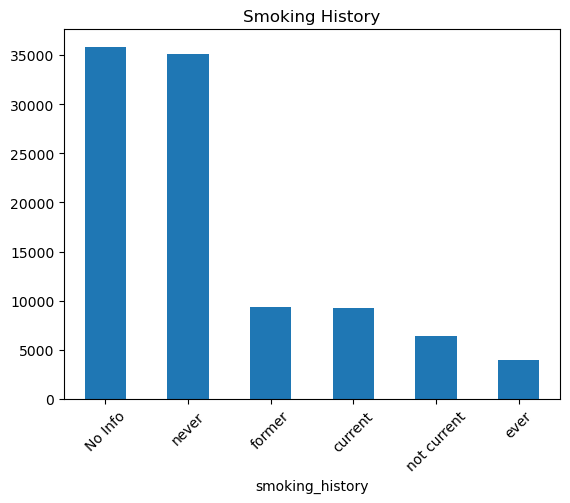

In [9]:
df["smoking_history"].value_counts().plot(kind="bar")
plt.title("Smoking History")
plt.xticks(rotation=45)
plt.show()


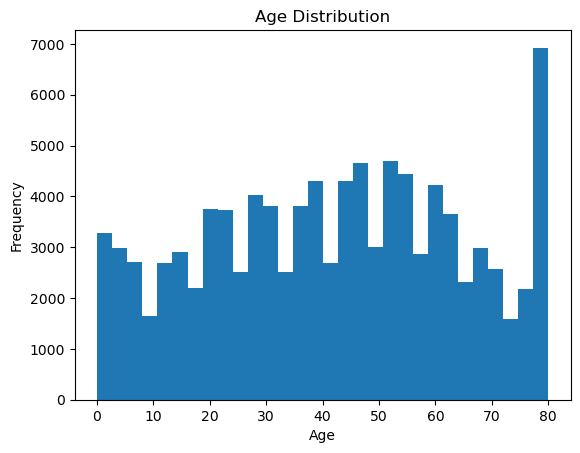

In [10]:
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [11]:

# count_77_80 = df[(df["age"] >= 75) & (df["age"] <= 76)].shape[0]

# print("Number of people aged 77 to 80:", count_77_80)


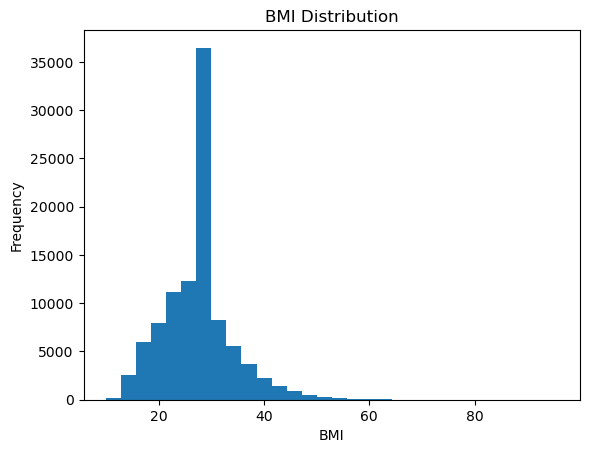

In [12]:
plt.hist(df["bmi"], bins=30)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

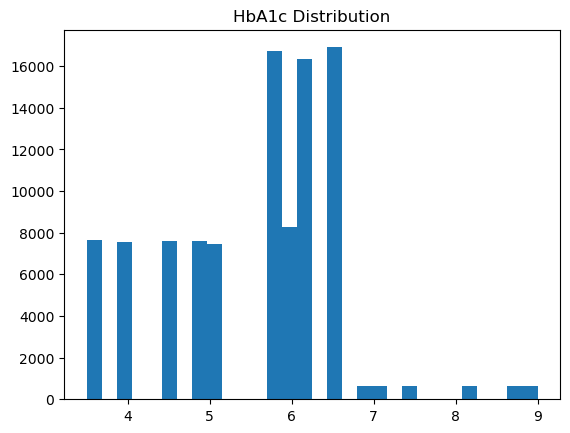

In [13]:
plt.hist(df["HbA1c_level"], bins=30)
plt.title("HbA1c Distribution")
plt.show()

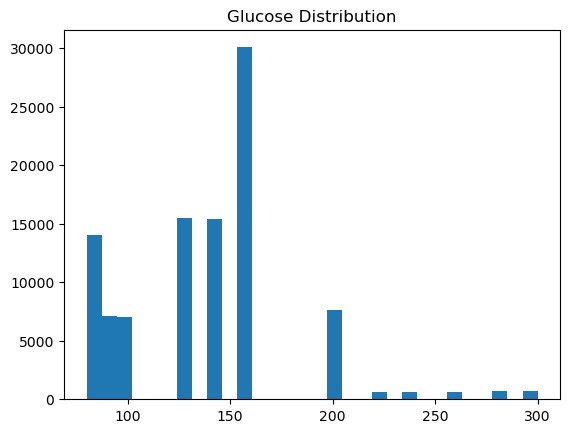

In [14]:
plt.hist(df["blood_glucose_level"], bins=30)
plt.title("Glucose Distribution")
plt.show()

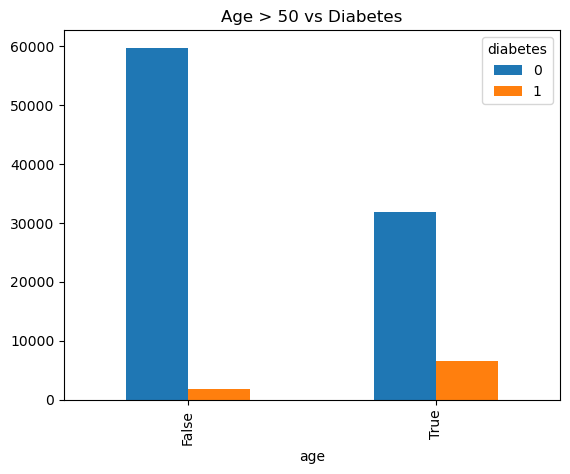

In [15]:
pd.crosstab(df["age"] > 50, df["diabetes"]).plot(kind="bar")
plt.title("Age > 50 vs Diabetes")
plt.show()

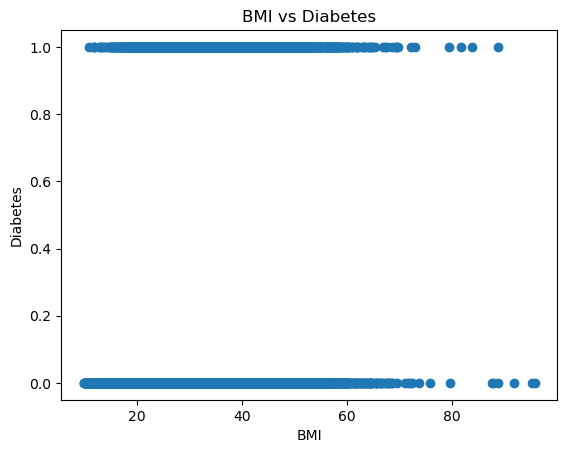

In [16]:
plt.scatter(df["bmi"], df["diabetes"])
plt.title("BMI vs Diabetes")
plt.xlabel("BMI")
plt.ylabel("Diabetes")
plt.show()

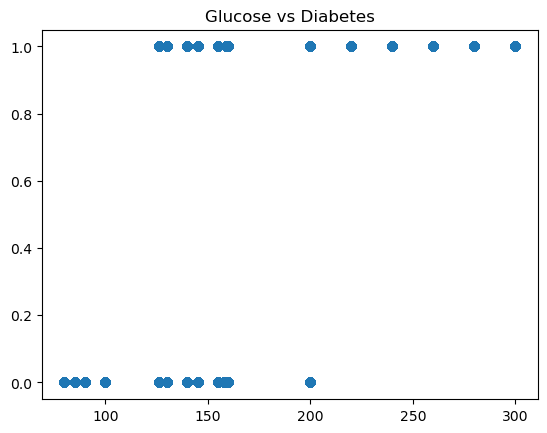

In [17]:
plt.scatter(df["blood_glucose_level"], df["diabetes"])
plt.title("Glucose vs Diabetes")
plt.show()

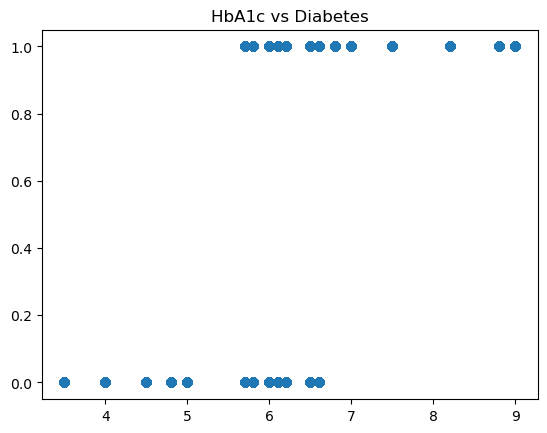

In [18]:
plt.scatter(df["HbA1c_level"], df["diabetes"])
plt.title("HbA1c vs Diabetes")
plt.show()

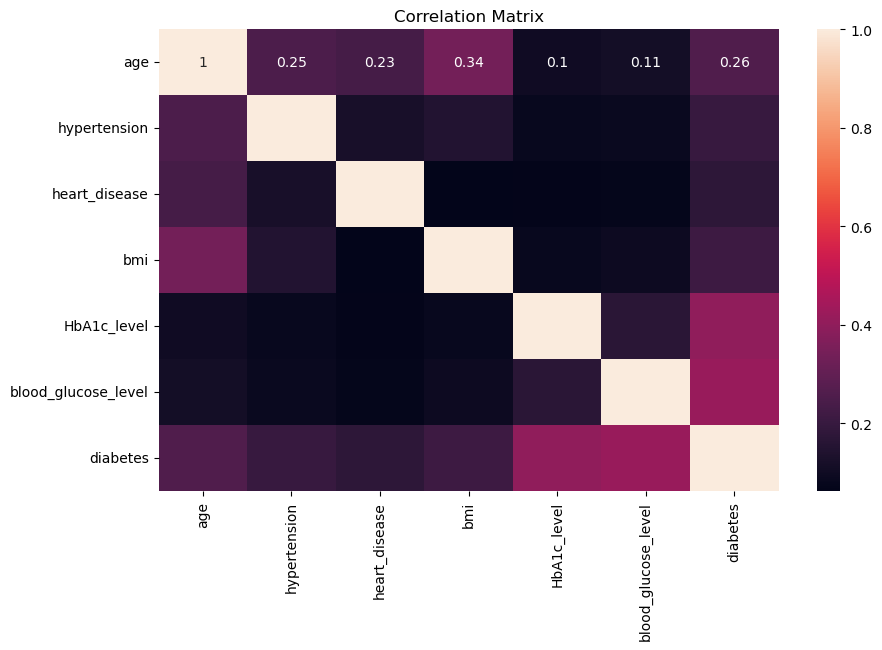

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [20]:
categorical_cols = ['gender', 'smoking_history']

data_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

data_encoded.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


In [21]:
df.sort_values(by="bmi", ascending=False).head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
87843,Male,7.0,0,0,No Info,95.69,6.1,130,0
76093,Male,16.0,0,0,No Info,95.22,4.5,90,0
69549,Male,38.0,0,0,never,91.82,6.0,160,0
96066,Male,80.0,0,0,never,88.76,6.2,140,0
4551,Female,45.0,0,0,never,88.72,7.0,300,1
90043,Female,34.0,0,0,No Info,87.70,6.0,126,0
22454,Male,19.0,0,0,No Info,87.51,3.5,85,0
24186,Male,49.0,0,0,former,83.74,6.8,155,1
71485,Female,48.0,0,0,never,81.73,6.5,130,1
20591,Female,39.0,0,0,No Info,79.48,4.8,155,0


In [22]:
categorical_cols = ["gender", "smoking_history"]

data_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Encoded Shape:", data_encoded.shape)
data_encoded.head()

Encoded Shape: (100000, 14)


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


In [23]:
X = data_encoded.drop("diabetes", axis=1)
y = data_encoded["diabetes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 13)
y shape: (100000,)


In [24]:
feature_names = X.columns.tolist()

os.makedirs("../code/models", exist_ok=True)
joblib.dump(feature_names, "../code/models/feature_names.pkl")

print("Feature names saved!")

Feature names saved!


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8889


In [31]:
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18300
           1       0.43      0.89      0.58      1700

    accuracy                           0.89     20000
   macro avg       0.71      0.89      0.76     20000
weighted avg       0.94      0.89      0.91     20000



In [32]:
dt = DecisionTreeClassifier(
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.88445


In [33]:
print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.88      0.93     18300
           1       0.42      0.93      0.58      1700

    accuracy                           0.88     20000
   macro avg       0.71      0.90      0.76     20000
weighted avg       0.94      0.88      0.90     20000



In [34]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=14,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.928


In [35]:
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     18300
           1       0.55      0.87      0.67      1700

    accuracy                           0.93     20000
   macro avg       0.77      0.90      0.82     20000
weighted avg       0.95      0.93      0.94     20000



In [36]:
xgb = XGBClassifier(
    n_estimators=350,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.97215


In [37]:

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.97      0.69      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.97      0.85      0.90     20000
weighted avg       0.97      0.97      0.97     20000



In [38]:
print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

Logistic Regression Accuracy: 0.8889
Decision Tree Accuracy: 0.88445
Random Forest Accuracy: 0.928
XGBoost Accuracy: 0.97215


In [41]:
if xgb_acc > rf_acc and xgb_acc > lr_acc and xgb_acc > dt_acc:
    final_model = xgb
    print("\n✅ Selected Model: XGBoost")

elif rf_acc > lr_acc and rf_acc > dt_acc:
    final_model = rf
    print("\n✅ Selected Model: Random Forest")

elif lr_acc > dt_acc:
    final_model = lr
    print("\n✅ Selected Model: Logistic Regression")

else:
    final_model = dt
    print("\n✅ Selected Model: Decision Tree")


✅ Selected Model: XGBoost


In [42]:
prob = final_model.predict_proba(X_test_scaled)[:, 1]

roc = roc_auc_score(y_test, prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.9798308743169399


In [43]:
importance = final_model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

imp_df

,Feature,Importance
4,HbA1c_level,0.516767
5,blood_glucose_level,0.255713
1,hypertension,0.051573
0,age,0.046057
2,heart_disease,0.043292
3,bmi,0.023765
6,gender_Male,0.013568
10,smoking_history_former,0.010360
9,smoking_history_ever,0.010251
8,smoking_history_current,0.009772


In [44]:
joblib.dump(final_model, "../code/models/diabetes_model.pkl")
joblib.dump(scaler, "../code/models/scaler.pkl")

print("✅ Model & Scaler Saved Successfully!")

✅ Model & Scaler Saved Successfully!
